In [1]:
import torch
from torch import nn , optim


# 转置卷积

In [ ]:
conv_t = nn.ConvTranspose2d(in_channels=3, out_channels=16,kernel_size=3,stride=2,padding=1,output_padding=1)

input = torch.randn(1,3,32,32)

output = conv_t(input)
print(output.shape)

torch.Size([1, 16, 64, 64])


##  去噪自编码器案例

In [2]:
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt


## 准备数据

In [3]:
# 1.加载原始图片
image = Image.open("Apple.jpg")
print(image)

<PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=600x574 at 0x115B1BB60>


In [5]:
# 1、定义图像转换操作（调整大小，转为Tensor）
transform = T.Compose([
    T.Resize((256,256)),
    T.ToTensor(),
])
#2、转换图片
img_tensor = transform(image)
print(img_tensor.shape)
print(img_tensor)

torch.Size([3, 256, 256])
tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])


In [6]:
#3、转换为ndarray,方便画图
img_numpy = img_tensor.permute(1,2,0).numpy()
print(img_numpy.shape)

(256, 256, 3)


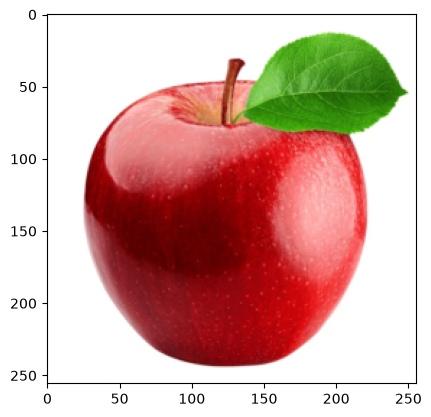

In [7]:
# 画图
plt.imshow(img_numpy)
plt.show()

In [10]:
#4、 加噪声，得到模型的输入
img_noise = img_tensor + torch.rand_like(img_tensor)*0.4

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00092618464..1.3999989].


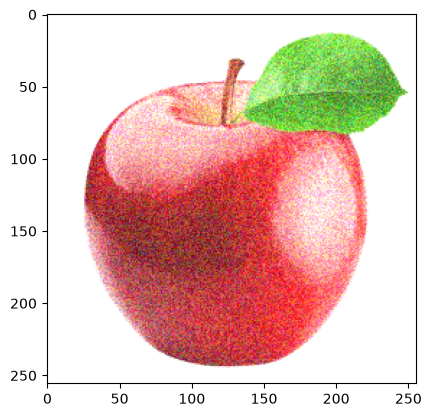

In [11]:
#5、 将噪声图像画图
img_noise_numpy = img_noise.permute(1,2,0).numpy()
plt.imshow(img_noise_numpy)
plt.show()

## 2、定义模型

In [18]:
# 定义自编码器（Autoencoder）的架构
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()  # 调用父类的构造函数，初始化模型

        # 编码器部分：将输入图像压缩为低维特征表示
        self.encoder = nn.Sequential(
            # 第一层卷积：输入通道数为 3（RGB 图像），输出通道数为 16，卷积核大小为 3x3，步长为 1，填充为 1
            # 输出尺寸：(16, 256, 256)
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),  # ReLU 激活函数，引入非线性
            # 最大池化层：池化核大小为 2x2，步长为 2，将图像尺寸减半
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 第二层卷积：输入通道数为 16，输出通道数为 8，卷积核大小为 3x3，步长为 1，填充为 1
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),  # ReLU 激活函数
            # 最大池化层：池化核大小为 2x2，步长为 2，将图像尺寸再次减半
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 解码器部分：将低维特征表示重构为原始图像
        self.decoder = nn.Sequential(
            # 第一层转置卷积：输入通道数为 8，输出通道数为 16，卷积核大小为 3x3，步长为 2，填充为 1，输出填充为 1
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),  # ReLU 激活函数
            # 第二层转置卷积：输入通道数为 16，输出通道数为 3，卷积核大小为 3x3，步长为 2，填充为 1，输出填充为 1
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Sigmoid 激活函数，将输出值限制在 [0, 1] 范围内，表示像素值
        )

    def forward(self, x):
        x = self.encoder(x)  # 对输入图像进行编码
        # print("encode shape: ", x.shape)
        x = self.decoder(x)  # 对编码后的特征进行解码，重构图像
        # print("decode shape: ", x.shape)
        return x

In [20]:
# 初始化自编码器模型
model = Autoencoder()

# 测试模型前向传播
x = model.forward(torch.randn(1, 3, 256, 256))

### 3、模型训练

In [21]:
# 将模型移动到 GPU（如果可用），否则使用 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # 打印当前使用的设备（GPU 或 CPU）
model.to(device)  # 将模型参数和缓冲区移动到指定设备

cpu


Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [22]:
# 定义损失函数和优化器
criterion = nn.MSELoss()  # 使用均方误差损失（MSE），衡量重构图像与原始图像的差异
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 使用 Adam 优化器，学习率为 0.001

In [24]:
# 训练自编码器
num_epochs = 400  # 训练的总轮数
for epoch in range(num_epochs):
    img = img_tensor.to(device)  # 将输入图像移动到指定设备
    optimizer.zero_grad()  # 清空梯度缓存，避免梯度累积
    output = model(img)  # 前向传播，获取重构图像
    loss = criterion(output, img)  # 计算损失（重构图像与原始图像的差异）
    loss.backward()  # 反向传播，计算梯度
    optimizer.step()  # 更新模型参数
    if (epoch+1) % 50 == 0:  # 每 50 轮打印一次损失值
        print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch + 1, num_epochs, loss.item()))



Epoch [50/400], Loss: 0.0031
Epoch [100/400], Loss: 0.0029
Epoch [150/400], Loss: 0.0027
Epoch [200/400], Loss: 0.0026
Epoch [250/400], Loss: 0.0025
Epoch [300/400], Loss: 0.0024
Epoch [350/400], Loss: 0.0023
Epoch [400/400], Loss: 0.0022


In [ ]:
# 保存训练好的模型
torch.save(model.state_dict(), 'conv_autoencoder.pth')